# 📊 Notebook 06 — Agent Evaluation: Accuracy, F1, Cohen's Kappa & More

## What this notebook does

This notebook evaluates **every specialist agent** (Sentiment, Noise, Discourse, Info, Helpfulness)
and the **Judge layer** using formal metrics:

| Metric | What it tells you |
|--------|------------------|
| **Accuracy** | % of predictions that exactly match ground truth |
| **F1 Score** | Balance between Precision and Recall (best for imbalanced labels) |
| **Cohen's Kappa** | Agreement beyond chance (are agents better than random?) |
| **MAE / RMSE** | How far off the numeric scores are on average |
| **Pearson / Spearman** | Correlation between predicted and true scores |
| **Confusion Matrix** | Which categories get confused with each other |
| **Inter-Agent Agreement** | Do agents contradict each other? |

## Two evaluation modes

- **Mode A — With ground truth labels** (gold standard): Requires a small manually-labelled CSV. 
  Used for Accuracy, F1, Kappa.
- **Mode B — Without ground truth** (self-evaluation): Uses heuristics + cross-agent agreement.
  Always available.

## Where to plug in your data
Look for `# ← CHANGE` comments — those are the only lines you need to edit.

## ⚙️ Cell 1 Imports & Paths

In [1]:
# Imports & paths ──────────────────────────────────────────────────────────
import json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
)
from scipy.stats import pearsonr, spearmanr

# ── ← CHANGE: set your project root ─────────────────────────────────────────
PROJECT_ROOT = Path(r"C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis")  # ← CHANGE

DATA_DIR    = PROJECT_ROOT / "data"
PROC_DIR    = DATA_DIR / "processed"
RESULTS_DIR = DATA_DIR / "results"
EVAL_DIR    = DATA_DIR / "evaluation"          # new folder — evaluation outputs go here
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports ready.")
print(f"   Results dir : {RESULTS_DIR}")
print(f"   Eval dir    : {EVAL_DIR}")

✅ Imports ready.
   Results dir : C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\results
   Eval dir    : C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation


## 📂 Cell 2  Load all agent results

In [4]:
# ── Load all per-video agent results (written by Notebook 03) ────────────────
# These files are named agent_result_<video_id>.json
# Each file contains: sentiment, noise, discourse, info, helpfulness dicts

def load_all_agent_results(results_dir: Path) -> dict:
    results = {}
    for p in sorted(results_dir.glob("agent_result_*.json")):
        vid_id = p.stem.replace("agent_result_", "")
        with open(p, encoding="utf-8") as f:
            results[vid_id] = json.load(f)
    return results

all_results = load_all_agent_results(RESULTS_DIR)
print(f"✅ Loaded {len(all_results)} agent result files.")

# ── Load final reports (written by Notebook 04) ──────────────────────────────
all_reports = []
for p in sorted(RESULTS_DIR.glob("final_report_*.json")):
    with open(p, encoding="utf-8") as f:
        all_reports.append(json.load(f))
print(f"✅ Loaded {len(all_reports)} final report files.")

# ── Build a flat summary DataFrame for analysis ──────────────────────────────
def safe(d, k, dv=0.0):
    if not isinstance(d, dict): return dv
    try: return float(d.get(k, dv))
    except: return dv

def is_fallback(d):
    return isinstance(d, dict) and d.get("explanation", "") == "heuristic fallback"


rows = []
for vid_id, r in all_results.items():
    rows = []
for vid_id, r in all_results.items():
    sentiment = r.get("sentiment")
    noise = r.get("noise")
    discourse = r.get("discourse")
    info = r.get("info")
    helpfulness = r.get("helpfulness")

    rows.append({
        "video_id": vid_id,
        "title": str(r.get("title", ""))[:50],

        "sentiment": safe(sentiment, "sentiment_score"),
        "noise": safe(noise, "noise_score"),
        "discourse": safe(discourse, "discourse_depth_score"),
        "info": safe(info, "info_density_score"),
        "helpfulness": safe(helpfulness, "helpfulness_score"),

        "sentiment_fallback": is_fallback(sentiment),
        "noise_fallback": is_fallback(noise),
        "discourse_fallback": is_fallback(discourse),
        "info_fallback": is_fallback(info),
        "helpfulness_fallback": is_fallback(helpfulness),
    })

scores_df = pd.DataFrame(rows)
SCORE_COLS = ["sentiment", "noise", "discourse", "info", "helpfulness"]
print(f"\nScores DataFrame shape: {scores_df.shape}")
print(scores_df[SCORE_COLS].describe().round(2))

✅ Loaded 55 agent result files.
✅ Loaded 43 final report files.

Scores DataFrame shape: (55, 12)
       sentiment  noise  discourse   info  helpfulness
count      55.00  55.00      55.00  55.00        55.00
mean        2.68   6.85       3.15   2.50         3.92
std         5.44   2.95       3.03   2.11         3.02
min        -9.60   0.00       0.00   0.00         0.00
25%        -0.35   6.00       0.00   0.00         0.00
50%         3.80   7.90       4.00   3.20         3.70
75%         7.40   8.75       6.00   3.55         6.00
max         9.20  10.00       8.00   8.00         9.00


## 🪣 Convert scores to categories (Low / Medium / High)

Most evaluation metrics (Accuracy, F1, Kappa) need **categorical labels**, not numbers.

We bucket the 0–10 scores into 3 tiers:
- `Low`    → score < 4
- `Medium` → 4 ≤ score < 7
- `High`   → score ≥ 7

In [5]:
# ── Convert continuous 0-10 scores to 3-class labels ─────────────────────────

def score_to_label(s: float) -> str:
    """Map a 0-10 score to Low / Medium / High."""
    if s < 4.0:  return "Low"
    if s < 7.0:  return "Medium"
    return "High"

for col in SCORE_COLS:
    scores_df[f"{col}_label"] = scores_df[col].apply(score_to_label)

LABEL_COLS = [f"{c}_label" for c in SCORE_COLS]

print("Label distributions per agent:")
for col in SCORE_COLS:
    counts = scores_df[f"{col}_label"].value_counts().to_dict()
    total  = len(scores_df)
    print(f"  {col:12s}: ", end="")
    for lbl in ["Low", "Medium", "High"]:
        n = counts.get(lbl, 0)
        print(f"{lbl}={n} ({100*n//total}%)  ", end="")
    print()

Label distributions per agent:
  sentiment   : Low=28 (50%)  Medium=6 (10%)  High=21 (38%)  
  noise       : Low=9 (16%)  Medium=10 (18%)  High=36 (65%)  
  discourse   : Low=27 (49%)  Medium=22 (40%)  High=6 (10%)  
  info        : Low=44 (80%)  Medium=9 (16%)  High=2 (3%)  
  helpfulness : Low=29 (52%)  Medium=15 (27%)  High=11 (20%)  


## ✅ MODE  Ground-Truth Evaluation

### What you need to do (one-time setup)

Create a CSV file called `ground_truth_labels.csv` in your `data/evaluation/` folder.
Label **at least 30–50 videos** manually (more is better).

The CSV must have these columns:

| Column | Values | Meaning |
|--------|--------|---------|
| `video_id` | e.g. `6FkRvTtUc-o` | Must match your agent results |
| `sentiment_true` | Low / Medium / High | Your human judgment of the comments' sentiment |
| `noise_true` | Low / Medium / High | How spammy/noisy are the comments? |
| `discourse_true` | Low / Medium / High | How deep is the intellectual discussion? |
| `info_true` | Low / Medium / High | How information-rich are the comments? |
| `helpfulness_true` | Low / Medium / High | How helpful are the comments to viewers? |
| `verdict_true` | worth_watching / caution / skip | Your overall video verdict |

### Example rows
```
video_id,sentiment_true,noise_true,discourse_true,info_true,helpfulness_true,verdict_true
6FkRvTtUc-o,High,High,High,High,High,worth_watching
abc123,Low,Low,Low,Low,Low,skip
xyz789,Medium,High,Medium,Medium,Medium,caution
```

**Tip:** Open `leaderboard.csv` in the results folder, add those columns, fill them in, save as `ground_truth_labels.csv`.

In [9]:
# ── Load your ground-truth CSV ────────────────────────────────────────────────

# ← CHANGE: path to your manually labelled CSV
GT_CSV = Path(r"C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation\"ground_truth_labels.csv") # ← CHANGE if your file is named differently

if GT_CSV.exists():
    gt = pd.read_csv(GT_CSV)
    print(f"✅ Ground truth loaded: {gt.shape[0]} rows, columns: {gt.columns.tolist()}")

    # Merge predictions with ground truth on video_id
    eval_df = scores_df.merge(gt, on="video_id", how="inner")
    print(f"   Matched videos for evaluation: {len(eval_df)}")

    if len(eval_df) < 10:
        print("⚠️  WARNING: fewer than 10 matched videos. Results will be unreliable.")
        print("   Label more videos in ground_truth_labels.csv for meaningful metrics.")
else:
    print(f"⚠️  Ground truth file not found at: {GT_CSV}")
    print("   Skipping Mode A (supervised metrics).")
    print("   Create the CSV as described above, then re-run this cell.")
    eval_df = None

⚠️  Ground truth file not found at: C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation\"ground_truth_labels.csv
   Skipping Mode A (supervised metrics).
   Create the CSV as described above, then re-run this cell.


## 📐  Compute Accuracy, F1, Cohen's Kappa per Agent

### What each metric means for your agents

**Accuracy** — simplest metric: what % of videos did the agent classify correctly?
- ≥ 80% → excellent
- 60–80% → acceptable
- < 60% → agent needs improvement

**F1 Score (macro)** — measures precision AND recall together, averaged across all classes.
This is more reliable than accuracy when your dataset has more "High" than "Low" videos.
- ≥ 0.75 → excellent
- 0.50–0.75 → acceptable
- < 0.50 → poor

**Cohen's Kappa** — measures agreement between the agent and you, *adjusted for chance*.
A random agent gets Kappa ≈ 0. A perfect agent gets Kappa = 1.0.
- ≥ 0.61 → substantial agreement
- 0.41–0.60 → moderate agreement
- 0.21–0.40 → fair agreement
- < 0.21 → poor (agent is barely better than random)

In [7]:
# ── Accuracy, F1, Kappa — requires ground truth CSV ──────────────────────────

if eval_df is not None and len(eval_df) >= 5:
    
    metric_rows = []

    for agent in SCORE_COLS:
        pred_col = f"{agent}_label"   # what the agent predicted (Low/Medium/High)
        true_col = f"{agent}_true"    # what you labelled

        if true_col not in eval_df.columns:
            print(f"⚠️  Column '{true_col}' missing in ground truth CSV — skipping {agent}")
            continue

        y_pred = eval_df[pred_col].values
        y_true = eval_df[true_col].values

        acc   = accuracy_score(y_true, y_pred)
        f1    = f1_score(y_true, y_pred, average="macro", zero_division=0)
        kappa = cohen_kappa_score(y_true, y_pred)

        # Interpretation
        kappa_interp = (
            "🟢 Substantial" if kappa >= 0.61 else
            "🟡 Moderate"    if kappa >= 0.41 else
            "🟠 Fair"        if kappa >= 0.21 else
            "🔴 Poor"
        )

        metric_rows.append({
            "Agent":       agent,
            "Accuracy":    round(acc, 3),
            "F1 (macro)":  round(f1, 3),
            "Kappa":       round(kappa, 3),
            "Kappa Interp": kappa_interp,
            "N":           len(eval_df),
        })

        print(f"\n{'─'*55}")
        print(f" Agent: {agent.upper()}")
        print(f"{'─'*55}")
        print(f"  Accuracy      : {acc:.1%}")
        print(f"  F1 (macro)    : {f1:.3f}")
        print(f"  Cohen's Kappa : {kappa:.3f}  →  {kappa_interp}")
        print(f"\n  Detailed classification report:")
        print(classification_report(y_true, y_pred, zero_division=0))

    metrics_df = pd.DataFrame(metric_rows)
    print("\n" + "="*60)
    print("SUMMARY TABLE")
    print("="*60)
    print(metrics_df.to_string(index=False))

    metrics_df.to_csv(EVAL_DIR / "classification_metrics.csv", index=False)
    print(f"\n✅ Saved: {EVAL_DIR / 'classification_metrics.csv'}")

else:
    print("⚠️  Skipping classification metrics — no ground truth data loaded.")
    print("   Create ground_truth_labels.csv and re-run Cell 4.")
    metrics_df = None

⚠️  Skipping classification metrics — no ground truth data loaded.
   Create ground_truth_labels.csv and re-run Cell 4.


## 📏 Cell 6 — Regression Metrics: MAE, RMSE, Pearson & Spearman Correlation

These work on the **raw 0–10 numeric scores** — no bucketing needed.

**MAE (Mean Absolute Error)** — average distance between predicted and true score.
- MAE of 0.5 means the agent is off by half a point on average → very good
- MAE of 2.0 means off by 2 points → needs improvement

**RMSE (Root Mean Squared Error)** — like MAE but penalises big mistakes more.
- RMSE > MAE always. A large gap means the agent makes occasional large errors.

**Pearson r** — measures linear relationship between predicted and true scores.
- r ≥ 0.8 → strong, r 0.5–0.8 → moderate, r < 0.5 → weak

**Spearman ρ** — measures rank correlation (does the agent rank videos in the right order?).
- More robust than Pearson when scores are not normally distributed.

In [10]:
# ── MAE / RMSE / Correlation — requires ground truth with numeric scores ─────
# Your ground truth CSV can optionally include numeric columns:
#   sentiment_score_true, noise_score_true, etc. (values 0-10)
# If you only have Low/Med/High labels, we convert them: Low=2, Medium=5.5, High=8

LABEL_TO_SCORE = {"Low": 2.0, "Medium": 5.5, "High": 8.0}

if eval_df is not None and len(eval_df) >= 5:

    reg_rows = []

    for agent in SCORE_COLS:
        pred_score_col = agent                    # predicted 0-10 score
        true_label_col = f"{agent}_true"          # Low/Medium/High human label
        true_score_col = f"{agent}_score_true"    # optional numeric label

        # Determine true numeric scores
        if true_score_col in eval_df.columns:
            y_true_num = eval_df[true_score_col].values.astype(float)
        elif true_label_col in eval_df.columns:
            y_true_num = eval_df[true_label_col].map(LABEL_TO_SCORE).values.astype(float)
        else:
            print(f"⚠️  No true score column for {agent} — skipping regression metrics")
            continue

        y_pred_num = eval_df[pred_score_col].values.astype(float)

        mae  = mean_absolute_error(y_true_num, y_pred_num)
        rmse = np.sqrt(mean_squared_error(y_true_num, y_pred_num))

        try:
            r_pearson,  p_p = pearsonr(y_true_num, y_pred_num)
            r_spearman, p_s = spearmanr(y_true_num, y_pred_num)
        except Exception:
            r_pearson = r_spearman = p_p = p_s = float('nan')

        reg_rows.append({
            "Agent":    agent,
            "MAE":      round(mae,  3),
            "RMSE":     round(rmse, 3),
            "Pearson r": round(r_pearson,  3),
            "Pearson p": round(p_p,        4),
            "Spearman ρ": round(r_spearman, 3),
            "Spearman p": round(p_s,        4),
        })

    reg_df = pd.DataFrame(reg_rows)
    print("\nRegression Metrics (lower MAE/RMSE = better, higher correlation = better)")
    print("="*70)
    print(reg_df.to_string(index=False))

    reg_df.to_csv(EVAL_DIR / "regression_metrics.csv", index=False)
    print(f"\n✅ Saved: {EVAL_DIR / 'regression_metrics.csv'}")

else:
    print("⚠️  No ground truth loaded. Showing score distribution only.")
    print(scores_df[SCORE_COLS].describe().round(2))

⚠️  No ground truth loaded. Showing score distribution only.
       sentiment  noise  discourse   info  helpfulness
count      55.00  55.00      55.00  55.00        55.00
mean        2.68   6.85       3.15   2.50         3.92
std         5.44   2.95       3.03   2.11         3.02
min        -9.60   0.00       0.00   0.00         0.00
25%        -0.35   6.00       0.00   0.00         0.00
50%         3.80   7.90       4.00   3.20         3.70
75%         7.40   8.75       6.00   3.55         6.00
max         9.20  10.00       8.00   8.00         9.00


## 🔬 MODE : Fallback Rate (no ground truth needed)

This measures **how often each agent failed and used the heuristic fallback**.
A high fallback rate means the LLM is not reliably returning JSON for that agent.

- Fallback rate < 10% → agent is working well
- Fallback rate 10–30% → agent is unstable, consider prompt improvement
- Fallback rate > 30% → agent is broken, needs attention

In [11]:
# ── Fallback rate per agent ───────────────────────────────────────────────────

fallback_cols = [f"{a}_fallback" for a in SCORE_COLS]
n = len(scores_df)

print("Agent Fallback Rates (fallback = LLM failed, used heuristic)")
print("="*55)

fb_rows = []
for agent in SCORE_COLS:
    fb_col = f"{agent}_fallback"
    if fb_col in scores_df.columns:
        fb_count = scores_df[fb_col].sum()
        fb_rate  = fb_count / n
        status = (
            "🟢 Good"    if fb_rate < 0.10 else
            "🟡 Warning" if fb_rate < 0.30 else
            "🔴 Broken"
        )
        print(f"  {agent:12s}: {fb_rate:.1%} ({fb_count}/{n})  {status}")
        fb_rows.append({"Agent": agent, "Fallback Count": int(fb_count),
                        "Fallback Rate": round(fb_rate, 3), "Status": status})
    else:
        print(f"  {agent:12s}: fallback tracking not available (check agent_result JSONs)")

fb_df = pd.DataFrame(fb_rows) if fb_rows else pd.DataFrame()

# Score variance — high variance means the agent is inconsistent
print("\nScore Variance per Agent (high variance may mean instability)")
print("="*55)
for agent in SCORE_COLS:
    std = scores_df[agent].std()
    mn  = scores_df[agent].mean()
    print(f"  {agent:12s}: mean={mn:.2f}  std={std:.2f}")

# Check for score range validity
print("\nScore Range Check (should all be 0–10)")
print("="*55)
for agent in SCORE_COLS:
    lo = scores_df[agent].min()
    hi = scores_df[agent].max()
    flag = "✅" if (lo >= 0 and hi <= 10) else "⚠️  OUT OF RANGE"
    print(f"  {agent:12s}: min={lo:.2f}  max={hi:.2f}  {flag}")

Agent Fallback Rates (fallback = LLM failed, used heuristic)
  sentiment   : 7.3% (4/55)  🟢 Good
  noise       : 21.8% (12/55)  🟡 Warning
  discourse   : 7.3% (4/55)  🟢 Good
  info        : 30.9% (17/55)  🔴 Broken
  helpfulness : 21.8% (12/55)  🟡 Warning

Score Variance per Agent (high variance may mean instability)
  sentiment   : mean=2.68  std=5.44
  noise       : mean=6.85  std=2.95
  discourse   : mean=3.15  std=3.03
  info        : mean=2.50  std=2.11
  helpfulness : mean=3.92  std=3.02

Score Range Check (should all be 0–10)
  sentiment   : min=-9.60  max=9.20  ⚠️  OUT OF RANGE
  noise       : min=0.00  max=10.00  ✅
  discourse   : min=0.00  max=8.00  ✅
  info        : min=0.00  max=8.00  ✅
  helpfulness : min=0.00  max=9.00  ✅


## 🤝  Inter-Agent Agreement

Do agents agree with each other? A sentiment agent saying a video is High quality while the
helpfulness agent says Low is a signal something may be wrong.

We compute **pairwise Kappa** between every pair of agents.

**What to look for:**
- Sentiment ↔ Helpfulness should have *moderate* agreement (both reflect viewer satisfaction)
- Noise ↔ Discourse should have *moderate* agreement (noisy comments are also shallow)
- Info ↔ Helpfulness should have *moderate* agreement (informative = helpful)
- Very **high** agreement between two agents could mean they are redundant
- Very **low** agreement means they truly measure different things (expected and acceptable)

Pairwise Cohen's Kappa between agents
(based on Low/Medium/High labels for each video)
  sentiment    vs noise       : κ = 0.241
  sentiment    vs discourse   : κ = 0.289
  sentiment    vs info        : κ = -0.037
  sentiment    vs helpfulness : κ = 0.099
  noise        vs discourse   : κ = 0.109
  noise        vs info        : κ = -0.003
  noise        vs helpfulness : κ = 0.107
  discourse    vs info        : κ = -0.048
  discourse    vs helpfulness : κ = -0.073
  info         vs helpfulness : κ = 0.067


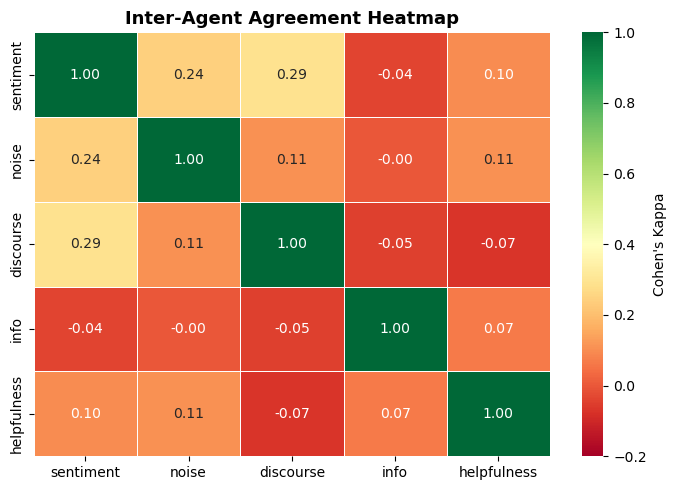

✅ Saved: C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation\inter_agent_kappa.png


In [12]:
# ── Pairwise Inter-Agent Kappa ────────────────────────────────────────────────

from itertools import combinations

print("Pairwise Cohen's Kappa between agents")
print("(based on Low/Medium/High labels for each video)")
print("="*55)

kappa_matrix = pd.DataFrame(index=SCORE_COLS, columns=SCORE_COLS, dtype=float)

for a1, a2 in combinations(SCORE_COLS, 2):
    try:
        k = cohen_kappa_score(
            scores_df[f"{a1}_label"],
            scores_df[f"{a2}_label"]
        )
    except Exception:
        k = float('nan')
    kappa_matrix.loc[a1, a2] = round(k, 3)
    kappa_matrix.loc[a2, a1] = round(k, 3)
    print(f"  {a1:12s} vs {a2:12s}: κ = {k:.3f}")

for a in SCORE_COLS:
    kappa_matrix.loc[a, a] = 1.0

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))
kappa_float = kappa_matrix.astype(float)
sns.heatmap(
    kappa_float, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-0.2, vmax=1.0, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Cohen's Kappa"}
)
ax.set_title("Inter-Agent Agreement Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "inter_agent_kappa.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {EVAL_DIR / 'inter_agent_kappa.png'}")

## 🔢  Confusion Matrices (requires ground truth)

Shows **which labels the agent confuses** with each other.

A well-performing agent should have most values on the diagonal (correct predictions).
Off-diagonal values reveal systematic errors:
- High predicted as Medium → agent is under-confident
- Low predicted as High → agent is dangerously wrong

In [13]:
# ── Confusion Matrices per agent ──────────────────────────────────────────────

if eval_df is not None and len(eval_df) >= 5:
    LABEL_ORDER = ["Low", "Medium", "High"]

    n_agents = len(SCORE_COLS)
    fig, axes = plt.subplots(1, n_agents, figsize=(4 * n_agents, 4))
    if n_agents == 1: axes = [axes]

    for ax, agent in zip(axes, SCORE_COLS):
        pred_col = f"{agent}_label"
        true_col = f"{agent}_true"

        if true_col not in eval_df.columns:
            ax.set_visible(False)
            continue

        cm = confusion_matrix(
            eval_df[true_col], eval_df[pred_col],
            labels=LABEL_ORDER
        )
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(agent.capitalize(), fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.suptitle("Confusion Matrices — Agent Predictions vs Ground Truth",
                 fontsize=13, y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.savefig(EVAL_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {EVAL_DIR / 'confusion_matrices.png'}")

else:
    print("⚠️  Ground truth not loaded — skipping confusion matrices.")

⚠️  Ground truth not loaded — skipping confusion matrices.


## ⚖️  Evaluate the Judge Layer (Final Verdict)

The Judge in Notebook 04 produces a final verdict: **worth_watching / caution / skip**.

We evaluate:
1. Distribution of verdicts (is the judge too strict/lenient?)
2. Accuracy of verdicts against your ground truth
3. Confidence calibration (does high confidence → high accuracy?)

Judge Verdict Distribution
  ⚠️ Watch with caution:   19 ( 44.2%)  ██████████████████████
  ✅ Worth watching    :   12 ( 27.9%)  █████████████
  ❌ Consider skipping :    8 ( 18.6%)  █████████
  ⚠️  Watch with caution:    4 (  9.3%)  ████

Average Confidence per Verdict
  ⚠️ Watch with caution: 71.8% avg confidence
  ✅ Worth watching    : 82.2% avg confidence
  ❌ Consider skipping : 80.1% avg confidence
  ⚠️  Watch with caution: 77.5% avg confidence

Score Distribution per Verdict
                        count  mean   std   min   25%   50%   75%   max
verdict                                                                
⚠️  Watch with caution    4.0  6.33  0.69  5.59  5.88  6.28  6.74  7.17
⚠️ Watch with caution    19.0  5.93  0.53  5.28  5.50  6.00  6.28  7.19
✅ Worth watching         12.0  8.09  1.00  6.86  7.39  7.96  8.91  9.50
❌ Consider skipping       8.0  3.77  1.54  0.00  3.98  4.34  4.47  4.57


C:\Users\user\AppData\Local\Temp\ipykernel_12256\1911377492.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12256\1911377492.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12256\1911377492.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(EVAL_DIR / "judge_evaluation.png", dpi=150, bbox_inches="tight")
C:\Users\user\AppData\Local\Temp\ipykernel_12256\1911377492.py:79: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(EVAL_DIR / "judge_evaluation.png", dpi=150, bbox_inches="tight")
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\

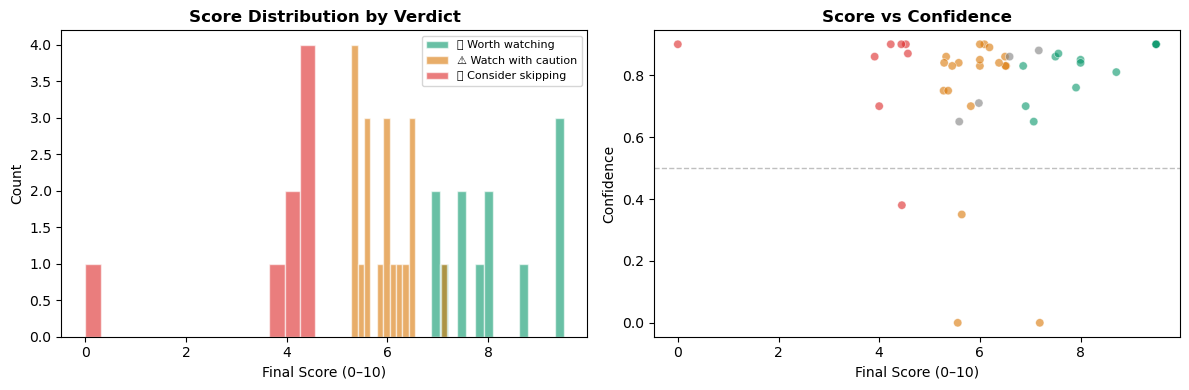


✅ Saved: C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation\judge_evaluation.png


In [14]:
# ── Judge layer evaluation ────────────────────────────────────────────────────

if all_reports:
    judge_df = pd.DataFrame([{
        "video_id":    r["video_id"],
        "final_score": r["final_score"],
        "verdict":     r["verdict"],
        "confidence":  r.get("confidence", 0.5),
    } for r in all_reports])

    # Distribution of verdicts
    print("Judge Verdict Distribution")
    print("="*45)
    verdict_counts = judge_df["verdict"].value_counts()
    for v, c in verdict_counts.items():
        pct = 100 * c / len(judge_df)
        bar = "█" * int(pct // 2)
        print(f"  {str(v):20s}: {c:4d} ({pct:5.1f}%)  {bar}")

    # Average confidence per verdict
    print("\nAverage Confidence per Verdict")
    print("="*45)
    for v in verdict_counts.index:
        avg_conf = judge_df[judge_df["verdict"] == v]["confidence"].mean()
        print(f"  {str(v):20s}: {avg_conf:.1%} avg confidence")

    # Score distribution per verdict
    print("\nScore Distribution per Verdict")
    print("="*45)
    print(judge_df.groupby("verdict")["final_score"].describe().round(2))

    # Verdict accuracy vs ground truth
    if eval_df is not None and "verdict_true" in eval_df.columns:
        judge_eval = judge_df.merge(
            eval_df[["video_id", "verdict_true"]], on="video_id", how="inner"
        )
        if len(judge_eval) >= 3:
            acc   = accuracy_score(judge_eval["verdict_true"], judge_eval["verdict"])
            f1    = f1_score(judge_eval["verdict_true"], judge_eval["verdict"],
                             average="macro", zero_division=0)
            kappa = cohen_kappa_score(judge_eval["verdict_true"], judge_eval["verdict"])
            print(f"\nJudge Overall Performance")
            print("="*45)
            print(f"  Accuracy      : {acc:.1%}")
            print(f"  F1 (macro)    : {f1:.3f}")
            print(f"  Cohen's Kappa : {kappa:.3f}")
            print(f"\n  Detailed report:")
            print(classification_report(judge_eval["verdict_true"], judge_eval["verdict"],
                                        zero_division=0))

    # Confidence calibration plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: Score distribution by verdict
    ax = axes[0]
    for v, color in [("✅ Worth watching", "#059669"), ("⚠️ Watch with caution", "#d97706"),
                     ("❌ Consider skipping", "#dc2626")]:
        subset = judge_df[judge_df["verdict"] == v]["final_score"]
        if len(subset) > 0:
            ax.hist(subset, bins=15, alpha=0.6, color=color, label=v, edgecolor="white")
    ax.set_xlabel("Final Score (0–10)"); ax.set_ylabel("Count")
    ax.set_title("Score Distribution by Verdict", fontweight="bold")
    ax.legend(fontsize=8)

    # Plot 2: Confidence vs Score scatter
    ax = axes[1]
    scatter_colors = judge_df["verdict"].map({
        "✅ Worth watching":     "#059669",
        "⚠️ Watch with caution": "#d97706",
        "❌ Consider skipping":  "#dc2626",
    }).fillna("gray")
    ax.scatter(judge_df["final_score"], judge_df["confidence"],
               c=scatter_colors, alpha=0.6, edgecolors="white", linewidths=0.5)
    ax.set_xlabel("Final Score (0–10)"); ax.set_ylabel("Confidence")
    ax.set_title("Score vs Confidence", fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, lw=1)

    plt.tight_layout()
    plt.savefig(EVAL_DIR / "judge_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ Saved: {EVAL_DIR / 'judge_evaluation.png'}")

else:
    print("⚠️  No final reports found. Run Notebook 04 first.")

## 📊  Score Distribution & Agent Health Dashboard

This visualisation shows:
1. How each agent distributes its scores across all videos (box plots)
2. Whether agents are biased (always returning the same score)
3. Which agents show the most variance

C:\Users\user\AppData\Local\Temp\ipykernel_12256\20192790.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[a[:4] for a in SCORE_COLS],


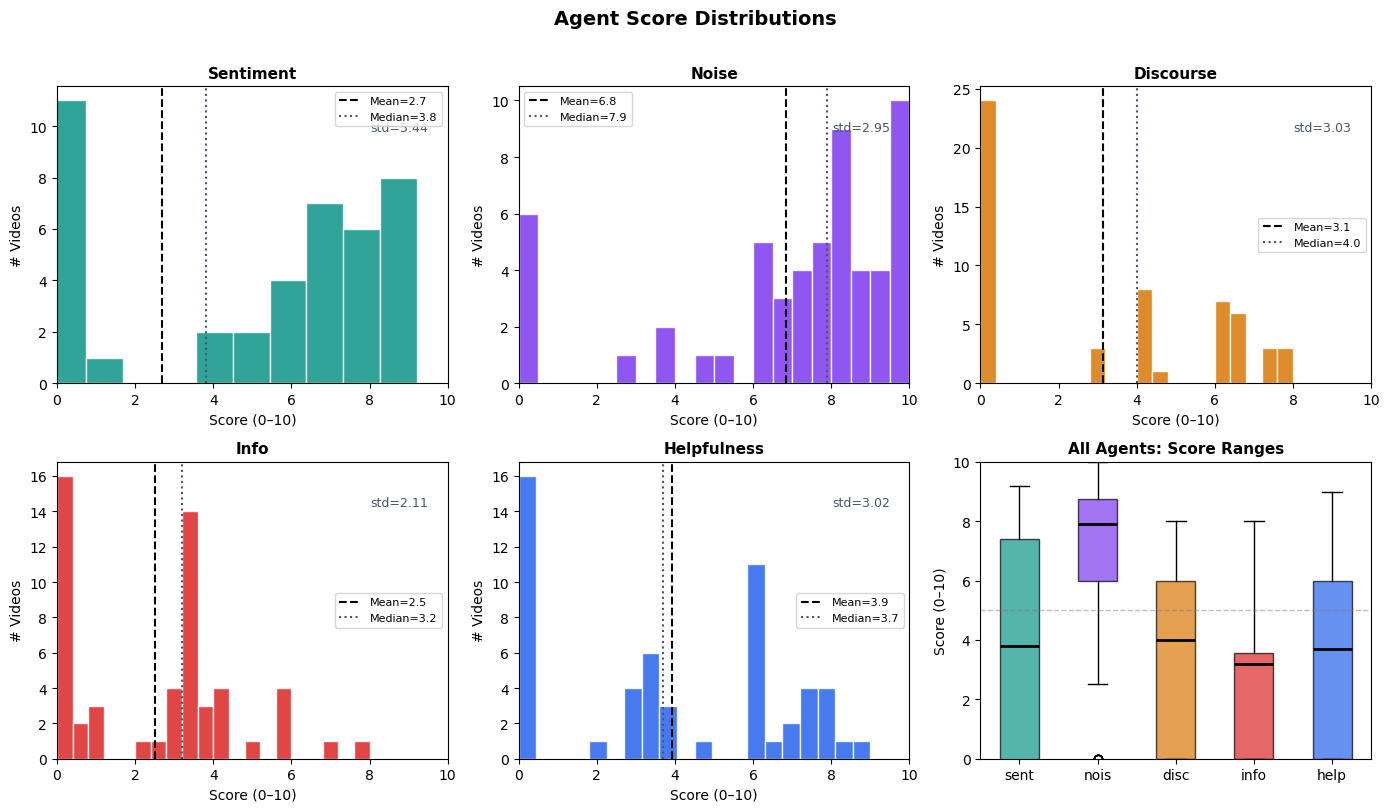

✅ Saved: C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation\score_distributions.png


In [15]:
# ── Agent Score Distribution Dashboard ───────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

COLORS = ["#0d9488", "#7c3aed", "#d97706", "#dc2626", "#2563eb"]

for idx, (agent, color) in enumerate(zip(SCORE_COLS, COLORS)):
    ax  = axes[idx]
    data = scores_df[agent].dropna()

    ax.hist(data, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black",  ls="--", lw=1.5, label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="#475569", ls=":",  lw=1.5, label=f"Median={data.median():.1f}")
    ax.set_xlim(0, 10)
    ax.set_title(agent.capitalize(), fontweight="bold", fontsize=11)
    ax.set_xlabel("Score (0–10)"); ax.set_ylabel("# Videos")
    ax.legend(fontsize=8)
    ax.text(0.95, 0.85, f"std={data.std():.2f}",
            transform=ax.transAxes, ha="right", fontsize=9, color="#475569")

# Last panel: box plot comparison
ax = axes[-1]
data_to_plot = [scores_df[a].dropna().values for a in SCORE_COLS]
bp = ax.boxplot(data_to_plot, labels=[a[:4] for a in SCORE_COLS],
                patch_artist=True, medianprops={"color": "black", "lw": 2})
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylim(0, 10)
ax.set_title("All Agents: Score Ranges", fontweight="bold", fontsize=11)
ax.set_ylabel("Score (0–10)")
ax.axhline(5, color="gray", ls="--", lw=1, alpha=0.5)

plt.suptitle("Agent Score Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(EVAL_DIR / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {EVAL_DIR / 'score_distributions.png'}")

## 🏁  Final Evaluation Summary Report

Combines all metrics into one report and flags agents that need attention.

In [16]:
# ── Final Summary ─────────────────────────────────────────────────────────────

summary = {}

print("\n" + "="*65)
print(" 📊  AGENT EVALUATION FINAL REPORT")
print("="*65)

for agent in SCORE_COLS:
    row = {"agent": agent}

    # Score stats (always available)
    data = scores_df[agent].dropna()
    row["mean_score"]   = round(data.mean(), 2)
    row["std_score"]    = round(data.std(), 2)
    row["score_range"]  = f"{data.min():.1f}–{data.max():.1f}"

    # Fallback rate
    fb_col = f"{agent}_fallback"
    if fb_col in scores_df.columns:
        row["fallback_rate"] = round(scores_df[fb_col].mean(), 3)
    else:
        row["fallback_rate"] = None

    # Supervised metrics (if available)
    if metrics_df is not None:
        m = metrics_df[metrics_df["Agent"] == agent]
        if not m.empty:
            row["accuracy"] = float(m["Accuracy"].iloc[0])
            row["f1"]       = float(m["F1 (macro)"].iloc[0])
            row["kappa"]    = float(m["Kappa"].iloc[0])

    summary[agent] = row

    # Print readable block
    print(f"\n  🤖 {agent.upper()}")
    print(f"     Score stats  : mean={row['mean_score']}, std={row['std_score']}, range={row['score_range']}")
    if row["fallback_rate"] is not None:
        fb = row["fallback_rate"]
        fb_flag = "🟢" if fb < 0.10 else ("🟡" if fb < 0.30 else "🔴")
        print(f"     Fallback rate: {fb:.1%}  {fb_flag}")
    if "accuracy" in row:
        acc_flag = "🟢" if row["accuracy"] >= 0.80 else ("🟡" if row["accuracy"] >= 0.60 else "🔴")
        k_flag   = "🟢" if row["kappa"]    >= 0.61 else ("🟡" if row["kappa"]    >= 0.41 else "🔴")
        print(f"     Accuracy     : {row['accuracy']:.1%}  {acc_flag}")
        print(f"     F1 (macro)   : {row['f1']:.3f}")
        print(f"     Kappa        : {row['kappa']:.3f}  {k_flag}")
    else:
        print(f"     Supervised   : (no ground truth — add ground_truth_labels.csv)")

# Save summary JSON
with open(EVAL_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)

print("\n" + "="*65)
print("✅ Full evaluation complete!")
print(f"   All outputs saved to: {EVAL_DIR}")
print("   Files produced:")
for p in sorted(EVAL_DIR.glob("*")):
    print(f"     - {p.name}")


 📊  AGENT EVALUATION FINAL REPORT

  🤖 SENTIMENT
     Score stats  : mean=2.68, std=5.44, range=-9.6–9.2
     Fallback rate: 7.3%  🟢
     Supervised   : (no ground truth — add ground_truth_labels.csv)

  🤖 NOISE
     Score stats  : mean=6.85, std=2.95, range=0.0–10.0
     Fallback rate: 21.8%  🟡
     Supervised   : (no ground truth — add ground_truth_labels.csv)

  🤖 DISCOURSE
     Score stats  : mean=3.15, std=3.03, range=0.0–8.0
     Fallback rate: 7.3%  🟢
     Supervised   : (no ground truth — add ground_truth_labels.csv)

  🤖 INFO
     Score stats  : mean=2.5, std=2.11, range=0.0–8.0
     Fallback rate: 30.9%  🔴
     Supervised   : (no ground truth — add ground_truth_labels.csv)

  🤖 HELPFULNESS
     Score stats  : mean=3.92, std=3.02, range=0.0–9.0
     Fallback rate: 21.8%  🟡
     Supervised   : (no ground truth — add ground_truth_labels.csv)

✅ Full evaluation complete!
   All outputs saved to: C:\Users\user\Documents\LLM - AI\Project\agentic_video_analysis\data\evaluation
   F

## 📖 Cell 13 — How to Interpret Your Results

Run this cell to get a personalised interpretation based on your actual scores.

In [17]:
# ── Personalised interpretation ───────────────────────────────────────────────

print("\n📖 HOW TO INTERPRET YOUR EVALUATION RESULTS")
print("="*65)

print("""
METRIC QUICK GUIDE
──────────────────
Accuracy: Overall % of correct Low/Medium/High predictions.
  ≥ 80%   → Your agent is very reliable
  60-80%  → Acceptable for a first version, improve prompts
  < 60%   → Agent is guessing, needs prompt redesign or better model

F1 Score (macro): Balances precision and recall across all 3 classes.
  ≥ 0.75  → Excellent
  0.5-0.75→ Acceptable
  < 0.5   → Poor; the agent is biased toward one class

Cohen's Kappa: Agreement BEYOND chance.
  ≥ 0.61  → Substantial — agent truly understands the task
  0.41-0.60 → Moderate — agent is useful but inconsistent
  0.21-0.40 → Fair — barely better than random, needs work
  < 0.21  → Poor — essentially random

MAE (Mean Absolute Error on 0-10 scale):
  < 0.75  → Very accurate
  0.75-1.5→ Acceptable
  > 1.5   → Agent scores too far from human judgement

Fallback Rate:
  < 10%   → Agent is stable
  10-30%  → Sometimes unstable; try a more capable LLM model
  > 30%   → Broken; LLM not returning JSON reliably

Inter-Agent Kappa:
  0.4-0.7 → Healthy: agents agree on easy cases, differ on hard ones
  > 0.8   → Possible redundancy: two agents measure the same thing
  < 0.2   → Agents completely disagree — check for a faulty agent
""") 

print("\nNEXT STEPS IF METRICS ARE LOW")
print("="*65)
print("""
1. HIGH FALLBACK RATE → Fix: improve the JSON prompt in Notebook 03.
   - Make sure your prompt ends with a concrete JSON example
   - Use model='llama3' instead of phi3 for better JSON reliability

2. LOW KAPPA (< 0.4) → Fix: the agent's scoring scale differs from humans.
   - Add few-shot examples to the prompt (2-3 examples with correct scores)
   - Narrow the scoring range (e.g., use 5 bands instead of 10)

3. HIGH MAE → Fix: the agent systematically over/under-scores.
   - Check if all scores cluster around 5 (model is playing safe)
   - Calibrate: multiply by a correction factor based on your MAE

4. POOR INTER-AGENT AGREEMENT (one agent always disagrees) →
   - That agent's prompt may be ambiguous
   - Check if that agent's fallback rate is high

5. JUDGE ACCURACY IS LOW → Fix: revisit the weights in WEIGHTS dict in Notebook 04.
   - For educational videos: increase info + discourse weights
   - For entertainment videos: increase sentiment + noise weights
""")


📖 HOW TO INTERPRET YOUR EVALUATION RESULTS

METRIC QUICK GUIDE
──────────────────
Accuracy: Overall % of correct Low/Medium/High predictions.
  ≥ 80%   → Your agent is very reliable
  60-80%  → Acceptable for a first version, improve prompts
  < 60%   → Agent is guessing, needs prompt redesign or better model

F1 Score (macro): Balances precision and recall across all 3 classes.
  ≥ 0.75  → Excellent
  0.5-0.75→ Acceptable
  < 0.5   → Poor; the agent is biased toward one class

Cohen's Kappa: Agreement BEYOND chance.
  ≥ 0.61  → Substantial — agent truly understands the task
  0.41-0.60 → Moderate — agent is useful but inconsistent
  0.21-0.40 → Fair — barely better than random, needs work
  < 0.21  → Poor — essentially random

MAE (Mean Absolute Error on 0-10 scale):
  < 0.75  → Very accurate
  0.75-1.5→ Acceptable
  > 1.5   → Agent scores too far from human judgement

Fallback Rate:
  < 10%   → Agent is stable
  10-30%  → Sometimes unstable; try a more capable LLM model
  > 30%   → 